In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
# from scipy.interpolate import RegularGridInterpolator
import MITgcmutils as mitgcm
import xmitgcm 
from xmitgcm.utils import read_mds
from matplotlib.path import Path

%matplotlib inline
import os
import imageio
import pandas as pd

import sys
from contextlib import contextmanager

from tqdm import tqdm
import psutil
import math
import gc

In [2]:
def get_ram_info():
    """
    Retrieves and prints detailed information about the system's RAM usage.
    """
    mem = psutil.virtual_memory()
    
    # Helper function to format bytes into human-readable units (GB)
    bytes_to_gb = lambda bytes_val: math.ceil(bytes_val / (1024**3))

    # print(f"Total RAM      : {bytes_to_gb(mem.total)} GB")
    # print(f"Available RAM  : {bytes_to_gb(mem.available)} GB")
    print(f"Used RAM  : {mem.used}")
    # print(f"Used RAM       : {bytes_to_gb(mem.used)} GB")
    # print(f"Used Percentage: {mem.percent}%")

get_ram_info()

Used RAM  : 7301128192


# for out diag files

In [3]:
# 0. parameters
rho0 = 1025  # kg/m3
g = 9.81  # m/s2
min_depth=20

In [4]:
# 1. read grid info
drF = read_mds('/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_barotropic/DRF',)
hFacW = read_mds('/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_barotropic/hFacW',)
hFacS = read_mds('/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_barotropic/hFacS',)
XC = read_mds('/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_barotropic/XC',)
XG = read_mds('/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_barotropic/XG',)
YC = read_mds('/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_barotropic/YC',)
RC = read_mds('/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_barotropic/RC',)
Depth = read_mds('/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_barotropic/Depth',)
maskC = read_mds('/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_barotropic/maskInC',)

lon = XC['XC'].compute()
lat = YC['YC'].compute()
depth_sea = Depth['Depth'].compute()
mask_sea = maskC['maskInC'].compute()

In [5]:
ds_masks = xr.open_dataset('masks_3basins.nc')

  0%|          | 0/1908 [00:00<?, ?it/s]

100%|██████████| 1908/1908 [00:13<00:00, 146.12it/s]


Text(0.5, 1.0, 'Makassar Strait Mask')

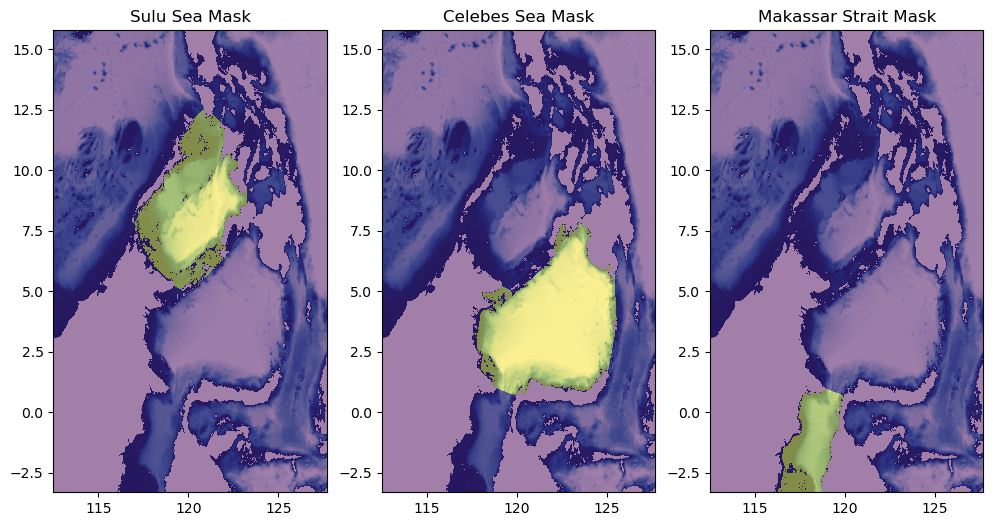

In [6]:
# 2. Define a mask for the Sulu Sea region
mask_sulu = np.zeros_like(maskC['maskInC'].compute())
mask_cele = np.zeros_like(maskC['maskInC'].compute())
mask_maka = np.zeros_like(maskC['maskInC'].compute())
# Define the polygon vertices for the Sulu Sea region
polygon1 = np.array([[119.7477305555556,5.019866666666666],
                    [120.7759136579978,5.474645071467973],
                    [122.0604127462074,6.418861725702965],
                    [122.0628562951826,6.950772011696411],
                    [122.4156305555556,7.857713888888888],
                    [123.2841972222222,8.224422222222222],
                    [123.2738388888889,9.305238888888889],
                    [123.0141444444444,9.580508333333334],
                    [123.2125075318087,10.77780565549861],
                    [121.9560470708515,11.85454899091673],
                    [120.9629975202234,12.58813464766382],
                    [120.2369776182294,12.10162143969847],
                    [119.9644441358147,11.66278768318502],
                    [119.4982072167793,11.19294905649988],
                    [119.5408523724053,10.66721177108409],
                    [117.7072365775101,8.913243570406612],
                    [116.9942048191374,7.818840574887203],
                    [117.0953880245524,7.260348599583542],
                    [117.4610027777778,5.793652777777778],
                    [119.0369305555556,5.263388888888889],
                    [119.7477305555556,5.019866666666666]
                ])
polygon2 = np.array([
                    [122.4156305555556,7.857713888888888],
                    [122.0628562951826,6.950772011696411],
                    [122.0604127462074,6.418861725702965],
                    [120.7759136579978,5.474645071467973],
                    [119.7477305555556,5.019866666666666],
                    [119.0369305555556,5.263388888888889],
                    [117.4610027777778,5.793652777777778],
                    [116.8239415753721,4.373865718248119],
                    [116.9949675073274,1.558713512219585],
                    [120.3555390294262,0.5651467190202299], 
                    [123.4819050887947,0.6174487079475919],
                    [124.3362386703296,0.7218080110272068], 
                    [125.0459513736719,1.56049707444234], 
                    [125.5646347020307,3.624570421021212], 
                    [125.4348070923769,5.731009669433583], 
                    [125.0783145681645,7.287851725018649], 
                    [123.2758350270172,8.171442179663259], 
                    [122.4156305555556,7.857713888888888],
                ])
polygon3 = np.array([
                    # [116.9591218380855,1.536846264008097],
                    [116.9949675073274,1.558713512219585],
                    [114.9619987677299,-3.295],
                    [119.5759922476142,-3.295] ,
                    [120.050971940272,-1.123578926929182],
                    [119.9073612391546,-0.448856717406894],
                    # [120.279550722386,0.5528591718648243],
                    [120.0183333333333,0.2],
                    [120.3555390294262,0.5651467190202299], 
                    [116.9949675073274,1.558713512219585]
                    # [116.9591218380855,1.536846264008097]
                ])

path1 = Path(polygon1) # sulu
path2 = Path(polygon2) # celebes
path3 = Path(polygon3) # makassar
for i in tqdm(range(mask_sulu.shape[0])):
    for j in range(mask_sulu.shape[1]):
        if path1.contains_point((lon[i, j], lat[i, j])):
            mask_sulu[i, j] = 1
            if (mask_sea[i, j] == 0) or (depth_sea[i, j] < min_depth):
                mask_sulu[i, j] = 0
        if path2.contains_point((lon[i, j], lat[i, j])):
            mask_cele[i, j] = 1
            if (mask_sea[i, j] == 0) or (depth_sea[i, j] < min_depth):
                mask_cele[i, j] = 0
        if path3.contains_point((lon[i, j], lat[i, j])):
            mask_maka[i, j] = 1
            if (mask_sea[i, j] == 0) or (depth_sea[i, j] < min_depth):
                mask_maka[i, j] = 0
fig, ax = plt.subplots(1,3,figsize=(12,6))
ax[0].pcolormesh(lon,lat,np.where(mask_sea==1,depth_sea,np.nan),cmap='Blues_r')
ax[1].pcolormesh(lon,lat,np.where(mask_sea==1,depth_sea,np.nan),cmap='Blues_r')
ax[2].pcolormesh(lon,lat,np.where(mask_sea==1,depth_sea,np.nan),cmap='Blues_r')
ax[0].pcolormesh(lon,lat,mask_sulu,alpha=0.5)
ax[1].pcolormesh(lon,lat,mask_cele,alpha=0.5)
ax[2].pcolormesh(lon,lat,mask_maka,alpha=0.5)
ax[0].set_title('Sulu Sea Mask')
ax[1].set_title('Celebes Sea Mask')
ax[2].set_title('Makassar Strait Mask')

In [11]:
ds_masks = xr.Dataset({
    'mask_sulu': (['YC', 'XC'], mask_sulu),
    'mask_cele': (['YC', 'XC'], mask_cele),
    'mask_maka': (['YC', 'XC'], mask_maka),
}, coords={'YC': lat[:,0], 'XC': lon[0,:]})

ds_masks.to_netcdf('masks_3basins.nc')

## read and calculate depth-averaged u/v (barotropic) from *ctrl* case

In [4]:
for im in range(5):
    u_ts = []
    get_ram_info()
    it1 = im*100
    it2 = (im+1)*100
    for it in range(it1,it2):
        print(f'Processing time step: {it}')
        itt = it*180
        u = read_mds(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/ctrl/outs_sn.{itt:010d}',)
        # u_ts.append(u['UVEL'][:,1000,700])
        u2d_2 = np.nansum(u['UVEL']*drF['DRF']*hFacW['hFacW'], axis=0)/np.nansum(drF['DRF']*hFacW['hFacW'], axis=0)
        u_ts.append(u2d_2)

    # convert u_ts to xarray dataset and save as netcdf
    u_ts_da = xr.DataArray(np.array(u_ts), dims=['time', 'YC', 'XG'])
    u_ts_da.to_netcdf(f'case_ctrl/u_2d_frombc_t_{it1}_to_{it2}.nc')

# plt.pcolormesh(u2d_2,vmax=0.01, vmin=-0.01,cmap='bwr')

Used RAM  : 9852805120
Processing time step: 0
Processing time step: 1
Processing time step: 2
Processing time step: 3
Processing time step: 4
Processing time step: 5
Processing time step: 6
Processing time step: 7
Processing time step: 8
Processing time step: 9
Processing time step: 10
Processing time step: 11
Processing time step: 12
Processing time step: 13
Processing time step: 14
Processing time step: 15
Processing time step: 16
Processing time step: 17
Processing time step: 18
Processing time step: 19
Processing time step: 20
Processing time step: 21
Processing time step: 22
Processing time step: 23
Processing time step: 24
Processing time step: 25
Processing time step: 26
Processing time step: 27
Processing time step: 28
Processing time step: 29
Processing time step: 30
Processing time step: 31
Processing time step: 32
Processing time step: 33
Processing time step: 34
Processing time step: 35
Processing time step: 36
Processing time step: 37
Processing time step: 38
Processing t

/home/ceoas/liux8/.conda/envs/py311/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


Used RAM  : 11671859200
Processing time step: 100
Processing time step: 101
Processing time step: 102
Processing time step: 103
Processing time step: 104
Processing time step: 105
Processing time step: 106
Processing time step: 107
Processing time step: 108
Processing time step: 109
Processing time step: 110
Processing time step: 111
Processing time step: 112
Processing time step: 113
Processing time step: 114
Processing time step: 115
Processing time step: 116
Processing time step: 117
Processing time step: 118
Processing time step: 119
Processing time step: 120
Processing time step: 121
Processing time step: 122
Processing time step: 123
Processing time step: 124
Processing time step: 125
Processing time step: 126
Processing time step: 127
Processing time step: 128
Processing time step: 129
Processing time step: 130
Processing time step: 131
Processing time step: 132
Processing time step: 133
Processing time step: 134
Processing time step: 135
Processing time step: 136
Processing tim

/home/ceoas/liux8/.conda/envs/py311/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


Used RAM  : 11456208896
Processing time step: 200
Processing time step: 201
Processing time step: 202
Processing time step: 203
Processing time step: 204
Processing time step: 205
Processing time step: 206
Processing time step: 207
Processing time step: 208
Processing time step: 209
Processing time step: 210
Processing time step: 211
Processing time step: 212
Processing time step: 213
Processing time step: 214
Processing time step: 215
Processing time step: 216
Processing time step: 217
Processing time step: 218
Processing time step: 219
Processing time step: 220
Processing time step: 221
Processing time step: 222
Processing time step: 223
Processing time step: 224
Processing time step: 225
Processing time step: 226
Processing time step: 227
Processing time step: 228
Processing time step: 229
Processing time step: 230
Processing time step: 231
Processing time step: 232
Processing time step: 233
Processing time step: 234
Processing time step: 235
Processing time step: 236
Processing tim

/home/ceoas/liux8/.conda/envs/py311/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


Used RAM  : 11603496960
Processing time step: 300
Processing time step: 301
Processing time step: 302
Processing time step: 303
Processing time step: 304
Processing time step: 305
Processing time step: 306
Processing time step: 307
Processing time step: 308
Processing time step: 309
Processing time step: 310
Processing time step: 311
Processing time step: 312
Processing time step: 313
Processing time step: 314
Processing time step: 315
Processing time step: 316
Processing time step: 317
Processing time step: 318
Processing time step: 319
Processing time step: 320
Processing time step: 321
Processing time step: 322
Processing time step: 323
Processing time step: 324
Processing time step: 325
Processing time step: 326
Processing time step: 327
Processing time step: 328
Processing time step: 329
Processing time step: 330
Processing time step: 331
Processing time step: 332
Processing time step: 333
Processing time step: 334
Processing time step: 335
Processing time step: 336
Processing tim

/home/ceoas/liux8/.conda/envs/py311/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


Used RAM  : 11592658944
Processing time step: 400
Processing time step: 401
Processing time step: 402
Processing time step: 403
Processing time step: 404
Processing time step: 405
Processing time step: 406
Processing time step: 407
Processing time step: 408
Processing time step: 409
Processing time step: 410
Processing time step: 411
Processing time step: 412
Processing time step: 413
Processing time step: 414
Processing time step: 415
Processing time step: 416
Processing time step: 417
Processing time step: 418
Processing time step: 419
Processing time step: 420
Processing time step: 421
Processing time step: 422
Processing time step: 423
Processing time step: 424
Processing time step: 425
Processing time step: 426
Processing time step: 427
Processing time step: 428
Processing time step: 429
Processing time step: 430
Processing time step: 431
Processing time step: 432
Processing time step: 433
Processing time step: 434
Processing time step: 435
Processing time step: 436
Processing tim

/home/ceoas/liux8/.conda/envs/py311/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


In [5]:
# v_ts = []

for im in range(5):
    v_ts = []
    get_ram_info()
    it1 = im*100
    it2 = (im+1)*100
    for it in range(it1,it2):
        print(f'Processing time step: {it}')
        itt = it*180
        v = read_mds(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/ctrl/outs_sn.{itt:010d}',)
        # v_ts.append(v['VVEL'][:,1000,700])
        v2d_2 = np.nansum(v['VVEL']*drF['DRF']*hFacS['hFacS'], axis=0)/np.nansum(drF['DRF']*hFacS['hFacS'], axis=0)
        v_ts.append(v2d_2)

    # convert v_ts to xarray dataset and save as netcdf
    v_ts_da = xr.DataArray(np.array(v_ts), dims=['time', 'YG', 'XC'])
    v_ts_da.to_netcdf(f'case_ctrl/v_2d_frombc_t_{it1}_to_{it2}.nc')

# for it in range(500,530):
#     print(f'Processing time step: {it}')
#     itt = it*180
#     v = read_mds(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/ctrl/outs_sn.{itt:010d}',)
#     # v_ts.append(v['VVEL'][:,1000,700])
#     v2d_2 = np.nansum(v['VVEL']*drF['DRF']*hFacS['hFacS'], axis=0)/np.nansum(drF['DRF']*hFacS['hFacS'], axis=0)
#     v_ts.append(v2d_2)

# # convert v_ts to xarray dataset and save as netcdf
# v_ts_da = xr.DataArray(np.array(v_ts), dims=['time', 'YG', 'XC'])
# v_ts_da.to_netcdf('case_ctrl/v_2d_frombc_t_500_to_530.nc')

# plt.pcolormesh(v2d_2,vmax=0.01, vmin=-0.01,cmap='bwr')

Used RAM  : 12250374144
Processing time step: 0
Processing time step: 1
Processing time step: 2
Processing time step: 3
Processing time step: 4
Processing time step: 5
Processing time step: 6
Processing time step: 7
Processing time step: 8
Processing time step: 9
Processing time step: 10
Processing time step: 11
Processing time step: 12
Processing time step: 13
Processing time step: 14
Processing time step: 15
Processing time step: 16
Processing time step: 17
Processing time step: 18
Processing time step: 19
Processing time step: 20
Processing time step: 21
Processing time step: 22
Processing time step: 23
Processing time step: 24
Processing time step: 25
Processing time step: 26
Processing time step: 27
Processing time step: 28
Processing time step: 29
Processing time step: 30
Processing time step: 31
Processing time step: 32
Processing time step: 33
Processing time step: 34
Processing time step: 35
Processing time step: 36
Processing time step: 37
Processing time step: 38
Processing 

/home/ceoas/liux8/.conda/envs/py311/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


Used RAM  : 12555194368
Processing time step: 100
Processing time step: 101
Processing time step: 102
Processing time step: 103
Processing time step: 104
Processing time step: 105
Processing time step: 106
Processing time step: 107
Processing time step: 108
Processing time step: 109
Processing time step: 110
Processing time step: 111
Processing time step: 112
Processing time step: 113
Processing time step: 114
Processing time step: 115
Processing time step: 116
Processing time step: 117
Processing time step: 118
Processing time step: 119
Processing time step: 120
Processing time step: 121
Processing time step: 122
Processing time step: 123
Processing time step: 124
Processing time step: 125
Processing time step: 126
Processing time step: 127
Processing time step: 128
Processing time step: 129
Processing time step: 130
Processing time step: 131
Processing time step: 132
Processing time step: 133
Processing time step: 134
Processing time step: 135
Processing time step: 136
Processing tim

/home/ceoas/liux8/.conda/envs/py311/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


Used RAM  : 12511596544
Processing time step: 200
Processing time step: 201
Processing time step: 202
Processing time step: 203
Processing time step: 204
Processing time step: 205
Processing time step: 206
Processing time step: 207
Processing time step: 208
Processing time step: 209
Processing time step: 210
Processing time step: 211
Processing time step: 212
Processing time step: 213
Processing time step: 214
Processing time step: 215
Processing time step: 216
Processing time step: 217
Processing time step: 218
Processing time step: 219
Processing time step: 220
Processing time step: 221
Processing time step: 222
Processing time step: 223
Processing time step: 224
Processing time step: 225
Processing time step: 226
Processing time step: 227
Processing time step: 228
Processing time step: 229
Processing time step: 230
Processing time step: 231
Processing time step: 232
Processing time step: 233
Processing time step: 234
Processing time step: 235
Processing time step: 236
Processing tim

/home/ceoas/liux8/.conda/envs/py311/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


Used RAM  : 12548984832
Processing time step: 300
Processing time step: 301
Processing time step: 302
Processing time step: 303
Processing time step: 304
Processing time step: 305
Processing time step: 306
Processing time step: 307
Processing time step: 308
Processing time step: 309
Processing time step: 310
Processing time step: 311
Processing time step: 312
Processing time step: 313
Processing time step: 314
Processing time step: 315
Processing time step: 316
Processing time step: 317
Processing time step: 318
Processing time step: 319
Processing time step: 320
Processing time step: 321
Processing time step: 322
Processing time step: 323
Processing time step: 324
Processing time step: 325
Processing time step: 326
Processing time step: 327
Processing time step: 328
Processing time step: 329
Processing time step: 330
Processing time step: 331
Processing time step: 332
Processing time step: 333
Processing time step: 334
Processing time step: 335
Processing time step: 336
Processing tim

/home/ceoas/liux8/.conda/envs/py311/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


Used RAM  : 12686221312
Processing time step: 400
Processing time step: 401
Processing time step: 402
Processing time step: 403
Processing time step: 404
Processing time step: 405
Processing time step: 406
Processing time step: 407
Processing time step: 408
Processing time step: 409
Processing time step: 410
Processing time step: 411
Processing time step: 412
Processing time step: 413
Processing time step: 414
Processing time step: 415
Processing time step: 416
Processing time step: 417
Processing time step: 418
Processing time step: 419
Processing time step: 420
Processing time step: 421
Processing time step: 422
Processing time step: 423
Processing time step: 424
Processing time step: 425
Processing time step: 426
Processing time step: 427
Processing time step: 428
Processing time step: 429
Processing time step: 430
Processing time step: 431
Processing time step: 432
Processing time step: 433
Processing time step: 434
Processing time step: 435
Processing time step: 436
Processing tim

/home/ceoas/liux8/.conda/envs/py311/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))


## read and calculate depth-averaged usur from barotropic case

In [15]:
for im in range(5):
    u_ts = []
    v_ts = []
    get_ram_info()
    it1 = im*100
    it2 = (im+1)*100
    for it in tqdm(range(it1,it2)):
        print(f'Processing time step: {it}')
        itt = it*180
        u = read_mds(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_barotropic/outs_sn.{itt:010d}',)
        # u_ts.append(u['UVEL'][:,1000,700])
        u2d_2 = u['UVEL'][0,:,:]
        u_ts.append(u2d_2)
        v2d_2 = u['VVEL'][0,:,:]
        v_ts.append(v2d_2)

    # convert u_ts to xarray dataset and save as netcdf
    u_ts_da = xr.DataArray(np.array(u_ts), dims=['time', 'YC', 'XG'])
    u_ts_da.to_netcdf(f'case_barotropic/u_2d_frombc_t_{it1}_to_{it2}.nc')
    v_ts_da = xr.DataArray(np.array(v_ts), dims=['time', 'YC', 'XG'])
    v_ts_da.to_netcdf(f'case_barotropic/v_2d_frombc_t_{it1}_to_{it2}.nc')

Used RAM  : 16267505664


 21%|██        | 21/100 [00:00<00:00, 206.83it/s]

Processing time step: 0
Processing time step: 1
Processing time step: 2
Processing time step: 3
Processing time step: 4
Processing time step: 5
Processing time step: 6
Processing time step: 7
Processing time step: 8
Processing time step: 9
Processing time step: 10
Processing time step: 11
Processing time step: 12
Processing time step: 13
Processing time step: 14
Processing time step: 15
Processing time step: 16
Processing time step: 17
Processing time step: 18
Processing time step: 19
Processing time step: 20
Processing time step: 21
Processing time step: 22
Processing time step: 23
Processing time step: 24
Processing time step: 25
Processing time step: 26
Processing time step: 27
Processing time step: 28
Processing time step: 29
Processing time step: 30
Processing time step: 31
Processing time step: 32
Processing time step: 33
Processing time step: 34
Processing time step: 35
Processing time step: 36
Processing time step: 37
Processing time step: 38
Processing time step: 39
Processing

 87%|████████▋ | 87/100 [00:00<00:00, 216.37it/s]

Processing time step: 43
Processing time step: 44
Processing time step: 45
Processing time step: 46
Processing time step: 47
Processing time step: 48
Processing time step: 49
Processing time step: 50
Processing time step: 51
Processing time step: 52
Processing time step: 53
Processing time step: 54
Processing time step: 55
Processing time step: 56
Processing time step: 57
Processing time step: 58
Processing time step: 59
Processing time step: 60
Processing time step: 61
Processing time step: 62
Processing time step: 63
Processing time step: 64
Processing time step: 65
Processing time step: 66
Processing time step: 67
Processing time step: 68
Processing time step: 69
Processing time step: 70
Processing time step: 71
Processing time step: 72
Processing time step: 73
Processing time step: 74
Processing time step: 75
Processing time step: 76
Processing time step: 77
Processing time step: 78
Processing time step: 79
Processing time step: 80
Processing time step: 81
Processing time step: 82


...

Processing time step: 400
Processing time step: 401
Processing time step: 402
Processing time step: 403
Processing time step: 404
Processing time step: 405
Processing time step: 406
Processing time step: 407
Processing time step: 408
Processing time step: 409
Processing time step: 410
Processing time step: 411
Processing time step: 412
Processing time step: 413
Processing time step: 414
Processing time step: 415
Processing time step: 416
Processing time step: 417
Processing time step: 418
Processing time step: 419
Processing time step: 420
Processing time step: 421
Processing time step: 422
Processing time step: 423
Processing time step: 424
Processing time step: 425
Processing time step: 426
Processing time step: 427
Processing time step: 428
Processing time step: 429
Processing time step: 430
Processing time step: 431
Processing time step: 432
Processing time step: 433
Processing time step: 434
Processing time step: 435
Processing time step: 436
Processing time step: 437
Processing t

 60%|██████    | 60/100 [00:00<00:00, 198.71it/s]

Processing time step: 439
Processing time step: 440
Processing time step: 441
Processing time step: 442
Processing time step: 443
Processing time step: 444
Processing time step: 445
Processing time step: 446
Processing time step: 447
Processing time step: 448
Processing time step: 449
Processing time step: 450
Processing time step: 451
Processing time step: 452
Processing time step: 453
Processing time step: 454
Processing time step: 455
Processing time step: 456
Processing time step: 457
Processing time step: 458
Processing time step: 459
Processing time step: 460
Processing time step: 461
Processing time step: 462
Processing time step: 463
Processing time step: 464
Processing time step: 465
Processing time step: 466
Processing time step: 467
Processing time step: 468
Processing time step: 469
Processing time step: 470
Processing time step: 471
Processing time step: 472
Processing time step: 473
Processing time step: 474
Processing time step: 475
Processing time step: 476
Processing t

100%|██████████| 100/100 [00:00<00:00, 201.26it/s]


Processing time step: 481
Processing time step: 482
Processing time step: 483
Processing time step: 484
Processing time step: 485
Processing time step: 486
Processing time step: 487
Processing time step: 488
Processing time step: 489
Processing time step: 490
Processing time step: 491
Processing time step: 492
Processing time step: 493
Processing time step: 494
Processing time step: 495
Processing time step: 496
Processing time step: 497
Processing time step: 498
Processing time step: 499


In [71]:
u_ts = []

for it in range(500,530):
    print(f'Processing time step for BT case: {it}')
    itt = it*180
    u = read_mds(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_barotropic/outs_sn.{itt:010d}',)
    # u_ts.append(u['UVEL'][:,1000,700])
    # u2d_2 = np.nansum(u['UVEL']*drF['DRF']*hFacW['hFacW'], axis=0)/np.nansum(drF['DRF']*hFacW['hFacW'], axis=0)
    u2d_2 = u['UVEL'][0,:,:]
    u_ts.append(u2d_2)

# convert u_ts to xarray dataset and save as netcdf
u_ts_da = xr.DataArray(np.array(u_ts), dims=['time', 'YC', 'XG'])
u_ts_da.to_netcdf('case_barotropic/u_2d_frombc_t_500_to_530.nc')

# plt.pcolormesh(u2d_2,vmax=0.01, vmin=-0.01,cmap='bwr')

Processing time step for BT case: 500
Processing time step for BT case: 501
Processing time step for BT case: 502
Processing time step for BT case: 503
Processing time step for BT case: 504
Processing time step for BT case: 505
Processing time step for BT case: 506
Processing time step for BT case: 507
Processing time step for BT case: 508
Processing time step for BT case: 509
Processing time step for BT case: 510
Processing time step for BT case: 511
Processing time step for BT case: 512
Processing time step for BT case: 513
Processing time step for BT case: 514
Processing time step for BT case: 515
Processing time step for BT case: 516
Processing time step for BT case: 517
Processing time step for BT case: 518
Processing time step for BT case: 519
Processing time step for BT case: 520
Processing time step for BT case: 521
Processing time step for BT case: 522
Processing time step for BT case: 523
Processing time step for BT case: 524
Processing time step for BT case: 525
Processing t

In [13]:
v_ts = []

for it in range(500,530):
    print(f'Processing time step for BT case: {it}')
    itt = it*180
    v = read_mds(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/case_barotropic/outs_sn.{itt:010d}',)
    v2d_2 = v['VVEL'][0,:,:]
    v_ts.append(v2d_2)
# convert v_ts to xarray dataset and save as netcdf
v_ts_da = xr.DataArray(np.array(v_ts), dims=['time', 'YG', 'XC'])
v_ts_da.to_netcdf('case_barotropic/v_2d_frombc_t_500_to_530.nc')

# plt.pcolormesh(v2d_2,vmax=0.01, vmin=-0.01,cmap='bwr')

Processing time step for BT case: 500
Processing time step for BT case: 501
Processing time step for BT case: 502
Processing time step for BT case: 503
Processing time step for BT case: 504
Processing time step for BT case: 505
Processing time step for BT case: 506
Processing time step for BT case: 507
Processing time step for BT case: 508
Processing time step for BT case: 509
Processing time step for BT case: 510
Processing time step for BT case: 511
Processing time step for BT case: 512
Processing time step for BT case: 513
Processing time step for BT case: 514
Processing time step for BT case: 515
Processing time step for BT case: 516
Processing time step for BT case: 517
Processing time step for BT case: 518
Processing time step for BT case: 519
Processing time step for BT case: 520
Processing time step for BT case: 521
Processing time step for BT case: 522
Processing time step for BT case: 523
Processing time step for BT case: 524
Processing time step for BT case: 525
Processing t

## plot U 2d of barotropic case and dep-averaged U of ctrl case for comparison

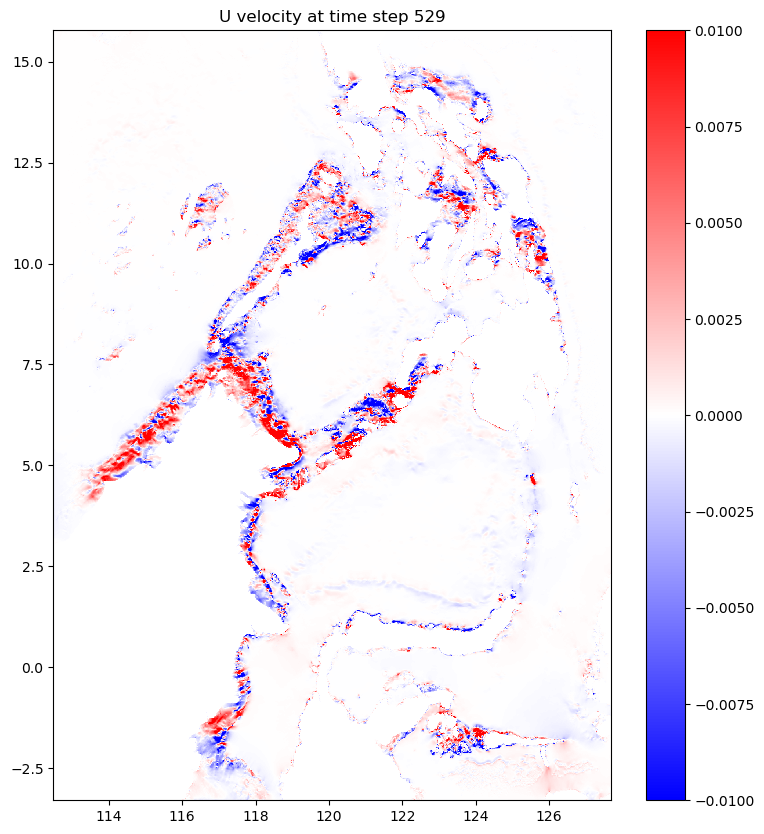

In [66]:
#check saved netcdf
ds_check = xr.open_dataset('case_ctrl/u_2d_frombc_t_500_to_530.nc')
ds_check['__xarray_dataarray_variable__']

fig, ax = plt.subplots(figsize=(9, 10))
cbar = None
for i in range(30):
    ax.clear()
    cs = ax.pcolormesh(ds_bt.XG, ds_bt.YC, ds_check['__xarray_dataarray_variable__'].isel(time=i),vmax=0.01, vmin=-0.01,cmap='bwr')
    if cbar is None:
        cbar = fig.colorbar(cs, ax=ax)
    else:
        cbar.update_normal(cs)
    # plt.colorbar(p, ax=ax)
    ax.set_title(f'U velocity at time step {500+i}')
    # plt.pause(0.5)

    plt.savefig(f'case_ctrl/u_2d_frombc_t_500_to_530_{i}.png')


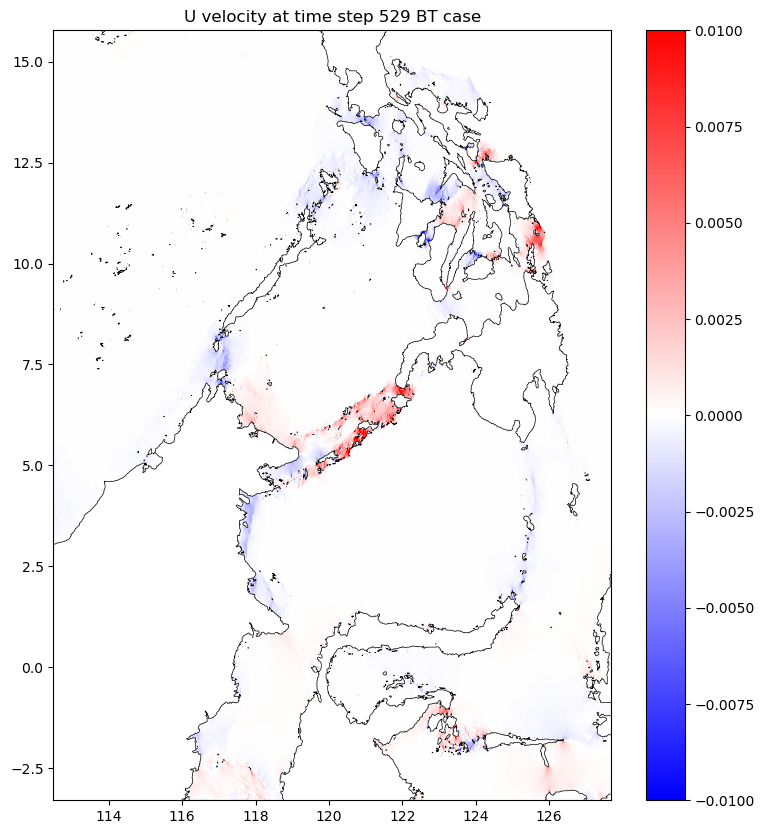

In [11]:
#check saved netcdf
ds_check = xr.open_dataset('case_barotropic/u_2d_frombc_t_500_to_530.nc')
ds_check['__xarray_dataarray_variable__']

fig, ax = plt.subplots(figsize=(9, 10))
cbar = None
for i in range(30):
    ax.clear()
    var_plt = ds_check['__xarray_dataarray_variable__'].isel(time=i)
    var_plt = var_plt.where(var_plt != 0)
    cs = ax.pcolormesh(XG['XG'], YC['YC'], var_plt,vmax=0.01, vmin=-0.01,cmap='bwr')
    if cbar is None:
        cbar = fig.colorbar(cs, ax=ax)
    else:
        cbar.update_normal(cs)
    ax.contour(XG['XG'].compute(), YC['YC'].compute(), hFacW['hFacW'][0].compute(), levels=[0], colors='k', linewidths=0.5)
    
    ax.set_title(f'U velocity at time step {500+i} BT case')
    # plt.pause(0.5)

    plt.savefig(f'case_barotropic/u_2d_frombc_t_500_to_530_{i}.png')


Processing time step for BC case: 500


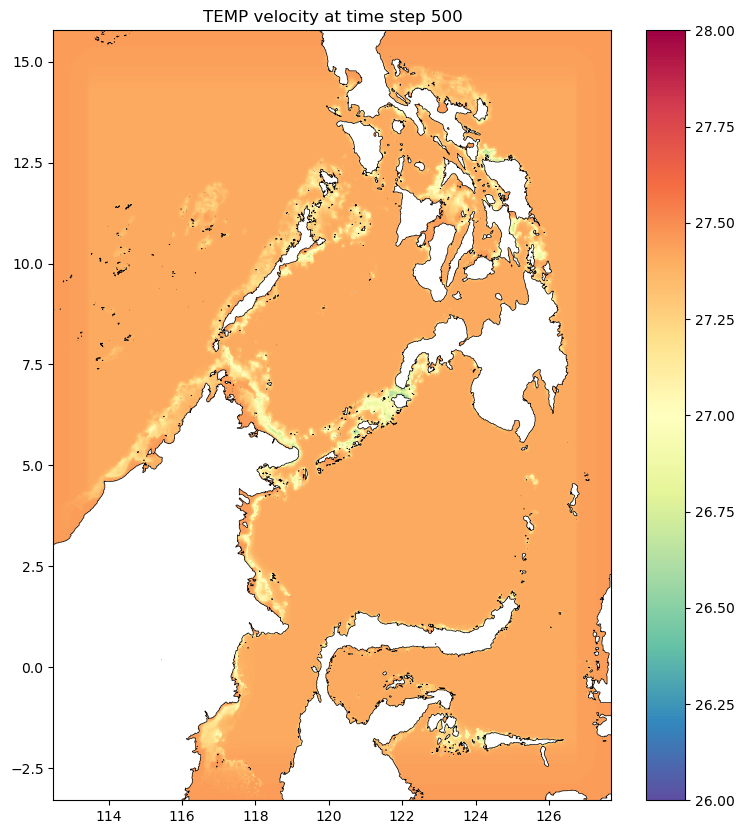

In [15]:
fig, ax = plt.subplots(figsize=(9, 10))
cbar = None
for it in range(500,501):
    print(f'Processing time step for BC case: {it}')
    itt = it*180
    u = read_mds(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/ctrl/outs_sn.{itt:010d}',)
    # u_ts.append(u['UVEL'][:,1000,700])
    # u2d_2 = np.nansum(u['UVEL']*drF['DRF']*hFacW['hFacW'], axis=0)/np.nansum(drF['DRF']*hFacW['hFacW'], axis=0)
    u2d_2 = u['THETA'][0,:,:]

    # u_ts.append(u2d_2)
    u2d_2[u2d_2==0]=np.nan
    ax.clear()
    cs = ax.pcolormesh(XC['XC'], YC['YC'], u2d_2,vmax=28, vmin=26,cmap='Spectral_r')
    if cbar is None:
        cbar = fig.colorbar(cs, ax=ax)
    else:
        cbar.update_normal(cs)
    ax.contour(XG['XG'].compute(), YC['YC'].compute(), hFacW['hFacW'][0].compute(), levels=[0], colors='k', linewidths=0.5)
    # plt.colorbar(p, ax=ax)
    ax.set_title(f'TEMP velocity at time step {it}')
    # plt.pause(0.5)

    plt.savefig(f'case_ctrl/tsur_frombc_t_500_to_530_{it}.png')
# # convert u_ts to xarray dataset and save as netcdf
# u_ts_da = xr.DataArray(np.array(u_ts), dims=['time', 'YC', 'XG'])
# u_ts_da.to_netcdf('case_barotropic/u_2d_frombc_t_500_to_530.nc')

# plt.pcolormesh(u2d_2,vmax=0.01, vmin=-0.01,cmap='bwr')

In [1]:
plt.pcolormesh(XC['XC'], YC['YC'], u2d_2,vmax=28, vmin=26,cmap='Spectral_r')
plt.xlim(116,122)
plt.ylim(5,8)
plt.hlines(5.705,118.3,119)
plt.colorbar()
plt.title('TEMP at time step 500')

NameError: name 'plt' is not defined

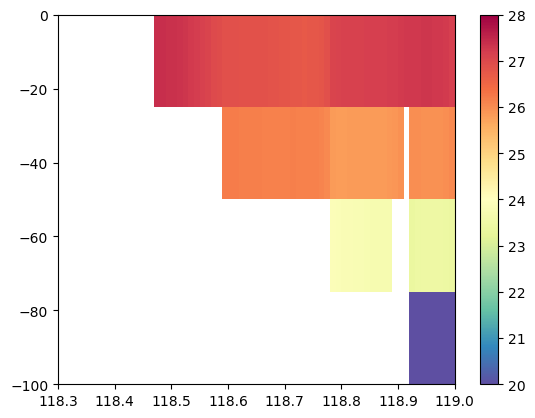

In [63]:
# np.array(YC['YC'][900,0])

# np.array(XC['XC'][0,850])

xp = XC['XC'][0,550:850]
yp = RC['RC'][:,0,0]
varp = u['THETA'][:,900,550:850]
varp = np.where(varp != 0, varp, np.nan)
# plt.contourf(xp, yp,  varp,vmax=28, vmin=15,cmap='Spectral_r',levels=np.arange(15,29,0.2))
plt.pcolormesh(xp, yp,  varp, vmax=28, vmin=20, cmap='Spectral_r')
plt.ylim(-100,0)
plt.xlim(118.3,119)
plt.colorbar()



## Calculate ENERGY
### should be done in 3 steps, (1) KE of barotropic test, (2) KE of BT enery of ctrl case, (3) KE BC energy of ctrl case 

### step 1. KE of barotropic case

In [6]:
### step 1. ke of the barotropic case at time step 500

ke_bt_btcase_tseries_hsum = []
ke_bt_btcase_tseries_sulu = []
ke_bt_btcase_tseries_cele = []
ke_bt_btcase_tseries_maka = []
for im in range(5):
    print(im)
    it1 = im*100
    it2 = (im+1)*100
    ds_bt_u = xr.open_dataset(f'case_barotropic/u_2d_frombc_t_{it1}_to_{it2}.nc')
    ds_bt_v = xr.open_dataset(f'case_barotropic/v_2d_frombc_t_{it1}_to_{it2}.nc')
    ke_bt = 0.5*(ds_bt_u['__xarray_dataarray_variable__'].values**2 
                 + ds_bt_v['__xarray_dataarray_variable__'].values**2) *Depth['Depth'].compute()* rho0
    ke_bt_hsum = np.nansum(ke_bt, axis=(1,2))
    ke_bt_sulu = np.nansum(ke_bt * mask_sulu, axis=(1,2))
    ke_bt_cele = np.nansum(ke_bt * mask_cele, axis=(1,2))
    ke_bt_maka = np.nansum(ke_bt * mask_maka, axis=(1,2))

    # ke_bt_tseries.append(ke_bt)
    ke_bt_btcase_tseries_hsum.append(ke_bt_hsum)
    ke_bt_btcase_tseries_sulu.append(ke_bt_sulu)
    ke_bt_btcase_tseries_cele.append(ke_bt_cele)
    ke_bt_btcase_tseries_maka.append(ke_bt_maka)
    get_ram_info()
ds_bt_u = xr.open_dataset(f'case_barotropic/u_2d_frombc_t_500_to_530.nc')
ds_bt_v = xr.open_dataset(f'case_barotropic/v_2d_frombc_t_500_to_530.nc')
ke_bt = 0.5*(ds_bt_u['__xarray_dataarray_variable__'].values**2 
                + ds_bt_v['__xarray_dataarray_variable__'].values**2) *Depth['Depth'].compute()* rho0
ke_bt_hsum = np.nansum(ke_bt, axis=(1,2))
ke_bt_sulu = np.nansum(ke_bt * mask_sulu, axis=(1,2))
ke_bt_cele = np.nansum(ke_bt * mask_cele, axis=(1,2))
ke_bt_maka = np.nansum(ke_bt * mask_maka, axis=(1,2))

    # ke_bt_tseries.append(ke_bt)
ke_bt_btcase_tseries_hsum.append(ke_bt_hsum)
ke_bt_btcase_tseries_sulu.append(ke_bt_sulu)
ke_bt_btcase_tseries_cele.append(ke_bt_cele)
ke_bt_btcase_tseries_maka.append(ke_bt_maka)

ke_bt_btcase_tseries_hsum = np.concatenate(ke_bt_btcase_tseries_hsum)
ke_bt_btcase_tseries_sulu = np.concatenate(ke_bt_btcase_tseries_sulu)
ke_bt_btcase_tseries_cele = np.concatenate(ke_bt_btcase_tseries_cele)
ke_bt_btcase_tseries_maka = np.concatenate(ke_bt_btcase_tseries_maka)


# save all the energy terms to a csv file
df_ke = pd.DataFrame({
    'ke_bt_total': ke_bt_btcase_tseries_hsum,
    'ke_bt_sulu': ke_bt_btcase_tseries_sulu,
    'ke_bt_cele': ke_bt_btcase_tseries_cele,
    'ke_bt_maka': ke_bt_btcase_tseries_maka,
})
df_ke.to_csv('case_barotropic_ke_bt_time_series.csv', index=False) 

0
Used RAM  : 21787607040
1
Used RAM  : 21895442432
2
Used RAM  : 21710389248
3
Used RAM  : 21739032576
4
Used RAM  : 21715066880


(0.0, 300000.0)

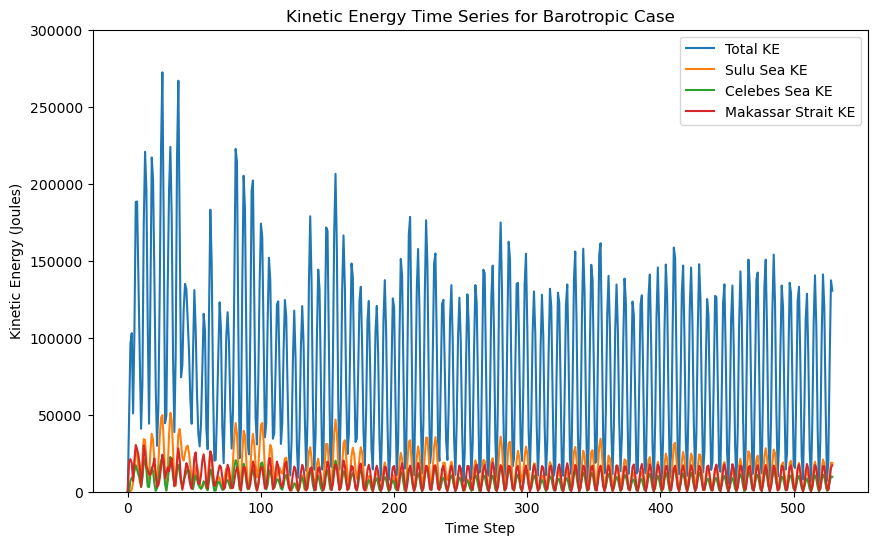

In [11]:
df_ke = pd.read_csv('case_barotropic_ke_bt_time_series.csv')
plt.figure(figsize=(10,6))
plt.plot(df_ke['ke_bt_total'], label='Total KE')
plt.plot(df_ke['ke_bt_sulu'], label='Sulu Sea KE')
plt.plot(df_ke['ke_bt_cele'], label='Celebes Sea KE')
plt.plot(df_ke['ke_bt_maka'], label='Makassar Strait KE')
# plt.yscale('log')
plt.xlabel('Time Step')
plt.ylabel('Kinetic Energy (Joules)')
plt.title('Kinetic Energy Time Series for Barotropic Case')
plt.legend()
plt.ylim(0,3e5)
# plt.grid()

Text(0, 0.5, 'Latitude')

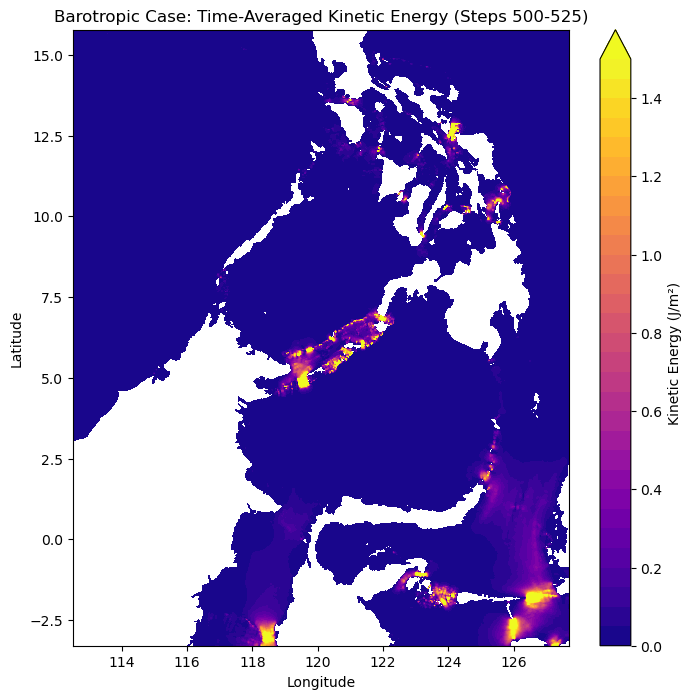

In [36]:
# barotropic case KE 
ds_bt_u = xr.open_dataset('case_barotropic/u_2d_frombc_t_500_to_530.nc')
ds_bt_v = xr.open_dataset('case_barotropic/v_2d_frombc_t_500_to_530.nc')

ke_bt_btcase = 0.5*(ds_bt_u['__xarray_dataarray_variable__'].values**2 + ds_bt_v['__xarray_dataarray_variable__'].values**2) * Depth['Depth'] * rho0
ke_bt_btcase_tavg = np.mean(ke_bt_btcase[0:25,:,:], axis=0)
ke_bt_btcase_tavg[ke_bt_btcase_tavg==0]=np.nan

plt.figure(figsize=(8,8))
plt.contourf(lon,lat,ke_bt_btcase_tavg,vmax=1.5, levels=np.arange(0,1.55,0.05), vmin=0,extend = 'max',cmap='plasma')
plt.colorbar(label='Kinetic Energy (J/m²)')
plt.title('Barotropic Case: Time-Averaged Kinetic Energy (Steps 500-525)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

### step 2. KE of BT enery of ctrl case

In [6]:
# ke_bt_tseries = []
ke_bt_tseries_hsum = []
ke_bt_tseries_sulu = []
ke_bt_tseries_cele = []
ke_bt_tseries_maka = []
for im in range(5):
    print(im)
    it1 = im*100
    it2 = (im+1)*100
    ds_bt_u = xr.open_dataset(f'case_ctrl/u_2d_frombc_t_{it1}_to_{it2}.nc')
    ds_bt_v = xr.open_dataset(f'case_ctrl/v_2d_frombc_t_{it1}_to_{it2}.nc')
    ke_bt = 0.5*(ds_bt_u['__xarray_dataarray_variable__'].values**2 
                 + ds_bt_v['__xarray_dataarray_variable__'].values**2) *Depth['Depth'].compute()* rho0
    ke_bt_hsum = np.nansum(ke_bt, axis=(1,2))
    ke_bt_sulu = np.nansum(ke_bt * mask_sulu, axis=(1,2))
    ke_bt_cele = np.nansum(ke_bt * mask_cele, axis=(1,2))
    ke_bt_maka = np.nansum(ke_bt * mask_maka, axis=(1,2))

    # ke_bt_tseries.append(ke_bt)
    ke_bt_tseries_hsum.append(ke_bt_hsum)
    ke_bt_tseries_sulu.append(ke_bt_sulu)
    ke_bt_tseries_cele.append(ke_bt_cele)
    ke_bt_tseries_maka.append(ke_bt_maka)
    get_ram_info()
ds_bt_u = xr.open_dataset(f'case_ctrl/u_2d_frombc_t_500_to_530.nc')
ds_bt_v = xr.open_dataset(f'case_ctrl/v_2d_frombc_t_500_to_530.nc')
ke_bt = 0.5*(ds_bt_u['__xarray_dataarray_variable__'].values**2 
                + ds_bt_v['__xarray_dataarray_variable__'].values**2) *Depth['Depth'].compute()* rho0
ke_bt_hsum = np.nansum(ke_bt, axis=(1,2))
ke_bt_sulu = np.nansum(ke_bt * mask_sulu, axis=(1,2))
ke_bt_cele = np.nansum(ke_bt * mask_cele, axis=(1,2))
ke_bt_maka = np.nansum(ke_bt * mask_maka, axis=(1,2))

    # ke_bt_tseries.append(ke_bt)
ke_bt_tseries_hsum.append(ke_bt_hsum)
ke_bt_tseries_sulu.append(ke_bt_sulu)
ke_bt_tseries_cele.append(ke_bt_cele)
ke_bt_tseries_maka.append(ke_bt_maka)

ke_bt_tseries_hsum = np.concatenate(ke_bt_tseries_hsum)
ke_bt_tseries_sulu = np.concatenate(ke_bt_tseries_sulu)
ke_bt_tseries_cele = np.concatenate(ke_bt_tseries_cele)
ke_bt_tseries_maka = np.concatenate(ke_bt_tseries_maka)

0
Used RAM  : 21825748992
1
Used RAM  : 21931274240
2
Used RAM  : 21885911040
3
Used RAM  : 21818753024
4
Used RAM  : 21794840576


In [7]:
# save all the energy terms to a csv file
df_ke = pd.DataFrame({
    'ke_bt_total': ke_bt_tseries_hsum,
    'ke_bt_sulu': ke_bt_tseries_sulu,
    'ke_bt_cele': ke_bt_tseries_cele,
    'ke_bt_maka': ke_bt_tseries_maka,
})
df_ke.to_csv('case_ctrl_ke_bt_time_series.csv', index=False) 

Text(0, 0.5, 'Kinetic Energy (J/m²)')

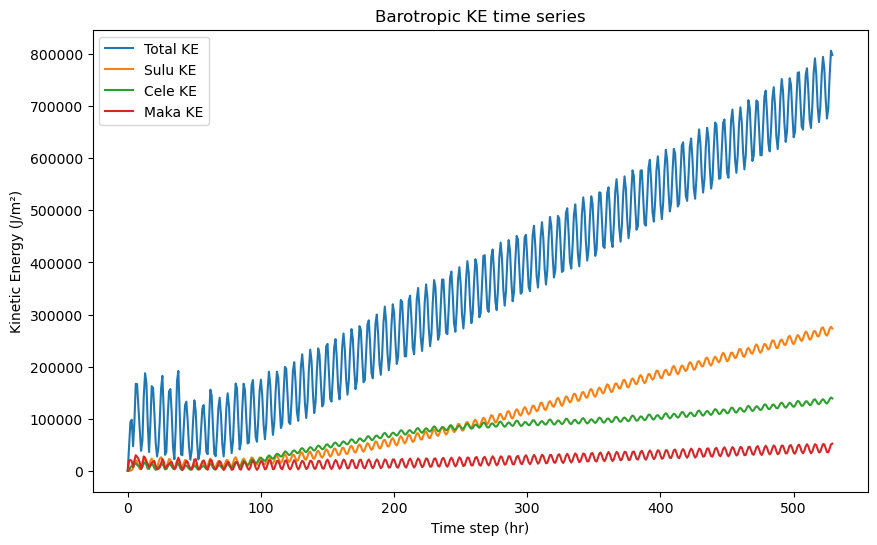

In [8]:
plt.figure(figsize=(10,6))
plt.plot(ke_bt_tseries_hsum, label='Total KE')
plt.plot(ke_bt_tseries_sulu, label='Sulu KE')
plt.plot(ke_bt_tseries_cele, label='Cele KE')
plt.plot(ke_bt_tseries_maka, label='Maka KE')
plt.legend()
plt.title('Barotropic KE time series')
plt.xlabel('Time step (hr)')
plt.ylabel('Kinetic Energy (J/m²)')

In [14]:
# barotropic case KE 
ds_bt_u = xr.open_dataset('case_ctrl/u_2d_frombc_t_500_to_530.nc')
ds_bt_v = xr.open_dataset('case_ctrl/v_2d_frombc_t_500_to_530.nc')

ke_bt_ctrl = 0.5*(ds_bt_u['__xarray_dataarray_variable__'].values**2 + ds_bt_v['__xarray_dataarray_variable__'].values**2) * Depth['Depth'] * rho0
ke_bt_ctrl_tavg = np.mean(ke_bt_ctrl[0:25,:,:], axis=0)
ke_bt_ctrl_tavg[ke_bt_ctrl_tavg==0]=np.nan

In [16]:
# barotropic case KE 
ds_bt_u = xr.open_dataset('case_ctrl/u_2d_frombc_t_500_to_530.nc')
ds_bt_v = xr.open_dataset('case_ctrl/v_2d_frombc_t_500_to_530.nc')

ke_bc_ctrl_tavg = []
for it in tqdm(range(25)):
    ds = read_mds(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/ctrl/outs_sn.{(500+it)*180:010d}',)
    u3d= ds['UVEL'].compute()-ds_bt_u['__xarray_dataarray_variable__'][it,:,:].values
    v3d = ds['VVEL'].compute()-ds_bt_v['__xarray_dataarray_variable__'][it,:,:].values
    ke_bc_ctrl = 0.5*(u3d**2 + v3d**2) * drF['DRF'].compute() * hFacW['hFacW'].compute() * rho0
    ke_bc_ctrl_vsum = np.nansum(ke_bc_ctrl, axis=0)
    ke_bc_ctrl_tavg.append(ke_bc_ctrl_vsum)
ke_bc_ctrl_tavg = np.mean(np.array(ke_bc_ctrl_tavg), axis=0)
    # ke_bc_ctrl_tavg[ke_bc_ctrl_tavg==0]=np.nan
ke_bc_ctrl_tavg[ke_bc_ctrl_tavg==0]=np.nan


  0%|          | 0/25 [00:00<?, ?it/s]

100%|██████████| 25/25 [02:12<00:00,  5.30s/it]


In [17]:
# save ke_bt_ctrl_tavg and ke_bc_ctrl_tavg as a netcdf file
ds = xr.Dataset(
    {
        "ke_bt_ctrl_tavg": (["j", "i"], ke_bt_ctrl_tavg),
        "ke_bc_ctrl_tavg": (["j", "i"], ke_bc_ctrl_tavg)
    },
    coords={
        "i": np.arange(0, ke_bt_ctrl_tavg.shape[1]),
        "j": np.arange(0, ke_bt_ctrl_tavg.shape[0]),
        "lon": (["j", "i"], lon),
        "lat": (["j", "i"], lat)
    }
)
ds.to_netcdf("case_ctrl_ke_vsum_tavg_500_525.nc")

Text(0, 0.5, 'Latitude')

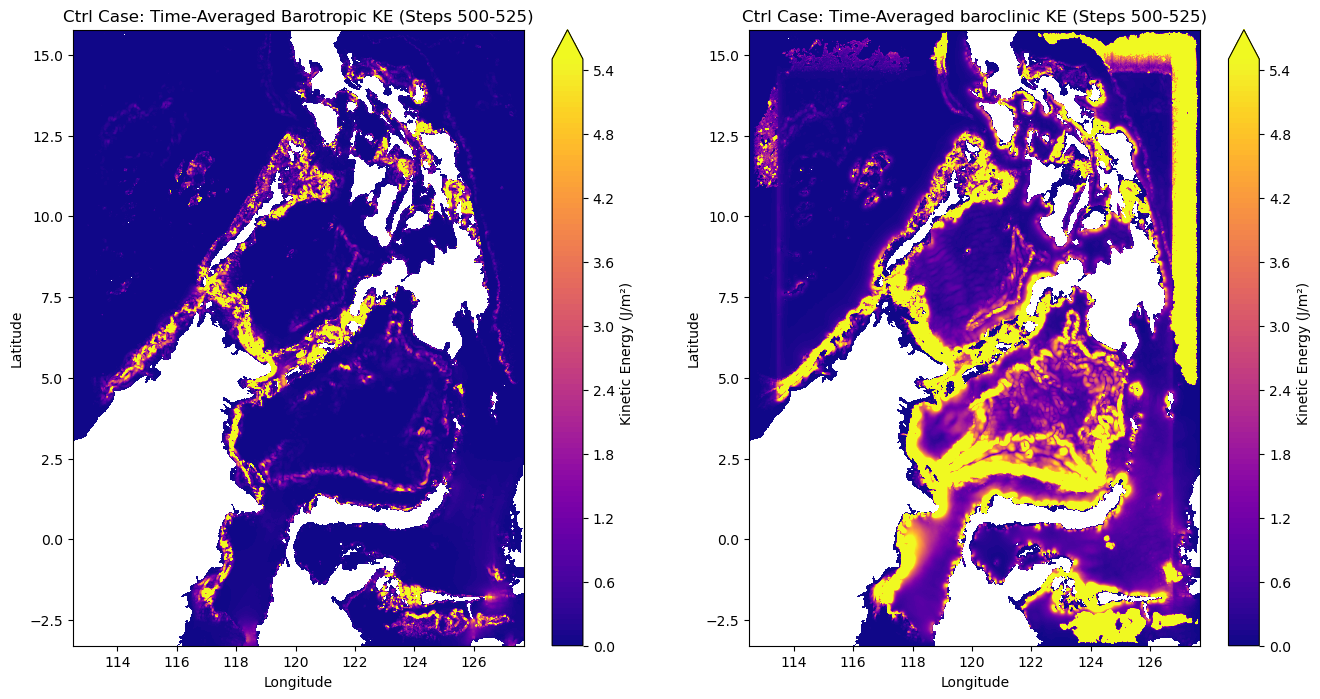

In [19]:
fig, ax = plt.subplots(1,2,figsize=(16,8))
am0 = ax[0].contourf(lon,lat,ke_bt_ctrl_tavg,vmax=5.5, levels=np.arange(0,5.55,0.05), vmin=0,extend = 'max',cmap='plasma')
plt.colorbar(am0,label='Kinetic Energy (J/m²)', ax=ax[0])
ax[0].set_title('Ctrl Case: Time-Averaged Barotropic KE (Steps 500-525)')
ax[0].set_xlabel('Longitude')
ax[0].set_ylabel('Latitude')
am1 = ax[1].contourf(lon,lat,ke_bc_ctrl_tavg,vmax=5.5, levels=np.arange(0,5.55,0.05), vmin=0,extend = 'max',cmap='plasma')
plt.colorbar(am1,label='Kinetic Energy (J/m²)', ax=ax[1])
ax[1].set_title('Ctrl Case: Time-Averaged baroclinic KE (Steps 500-525)')
ax[1].set_xlabel('Longitude')
ax[1].set_ylabel('Latitude')

In [32]:
## calculate Baroclinic KE
ke_bc_tseries_hsum = []
ke_bc_tseries_sulu = []
ke_bc_tseries_cele = []
ke_bc_tseries_maka = []

for im in range(5):
    it1 = im*100
    it2 = (im+1)*100
    ds_bt_u = xr.open_dataset(f'case_ctrl/u_2d_frombc_t_{it1}_to_{it2}.nc')
    ds_bt_v = xr.open_dataset(f'case_ctrl/v_2d_frombc_t_{it1}_to_{it2}.nc')
    get_ram_info()
    u2d = ds_bt_u['__xarray_dataarray_variable__'].values
    v2d = ds_bt_v['__xarray_dataarray_variable__'].values
    for it in tqdm(range(it1, it2)):
        # print(f'Processing time step for BC case: {it}')
        itt = it*180
        u = read_mds(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/ctrl/outs_sn.{itt:010d}',)
        v = read_mds(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/ctrl/outs_sn.{itt:010d}',)

        ubc = u['UVEL'].compute() - u2d[it-it1]
        vbc = v['VVEL'].compute() - v2d[it-it1]

        ke_bc = 0.5*(ubc**2 + vbc**2) * drF['DRF'].compute() * hFacS['hFacS'].compute()* rho0
        ke_bc_hsum = np.nansum(ke_bc, axis=(0,1,2))
        ke_bc_sulu = np.nansum(ke_bc * mask_sulu, axis=(0,1,2))
        ke_bc_cele = np.nansum(ke_bc * mask_cele, axis=(0,1,2))
        ke_bc_maka = np.nansum(ke_bc * mask_maka, axis=(0,1,2))
        ke_bc_tseries_hsum.append(ke_bc_hsum)
        ke_bc_tseries_sulu.append(ke_bc_sulu)
        ke_bc_tseries_cele.append(ke_bc_cele)
        ke_bc_tseries_maka.append(ke_bc_maka)


Used RAM  : 15732441088


100%|██████████| 100/100 [10:22<00:00,  6.23s/it]


Used RAM  : 13871513600


100%|██████████| 100/100 [10:27<00:00,  6.27s/it]


Used RAM  : 13897498624


100%|██████████| 100/100 [10:52<00:00,  6.53s/it]


Used RAM  : 13880844288


100%|██████████| 100/100 [12:02<00:00,  7.23s/it]


Used RAM  : 14127710208


100%|██████████| 100/100 [11:24<00:00,  6.85s/it]


In [40]:
ds_bt_u = xr.open_dataset(f'case_ctrl/u_2d_frombc_t_500_to_530.nc')
ds_bt_v = xr.open_dataset(f'case_ctrl/v_2d_frombc_t_500_to_530.nc')
get_ram_info()
u2d = ds_bt_u['__xarray_dataarray_variable__'].values
v2d = ds_bt_v['__xarray_dataarray_variable__'].values
for it in tqdm(range(500, 530)):
    # print(f'Processing time step for BC case: {it}')
    itt = it*180
    u = read_mds(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/ctrl/outs_sn.{itt:010d}',)
    v = read_mds(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/ctrl/outs_sn.{itt:010d}',)

    ubc = u['UVEL'].compute() - u2d[it-500]
    vbc = v['VVEL'].compute() - v2d[it-500]

    ke_bc = 0.5*(ubc**2 + vbc**2) * drF['DRF'].compute() * hFacS['hFacS'].compute()* rho0
    ke_bc_hsum = np.nansum(ke_bc, axis=(0,1,2))
    ke_bc_sulu = np.nansum(ke_bc * mask_sulu, axis=(0,1,2))
    ke_bc_cele = np.nansum(ke_bc * mask_cele, axis=(0,1,2))
    ke_bc_maka = np.nansum(ke_bc * mask_maka, axis=(0,1,2))
    ke_bc_tseries_hsum.append(ke_bc_hsum)
    ke_bc_tseries_sulu.append(ke_bc_sulu)
    ke_bc_tseries_cele.append(ke_bc_cele)
    ke_bc_tseries_maka.append(ke_bc_maka)

Used RAM  : 13760294912


100%|██████████| 30/30 [03:26<00:00,  6.87s/it]


Text(0, 0.5, 'Kinetic Energy (J)')

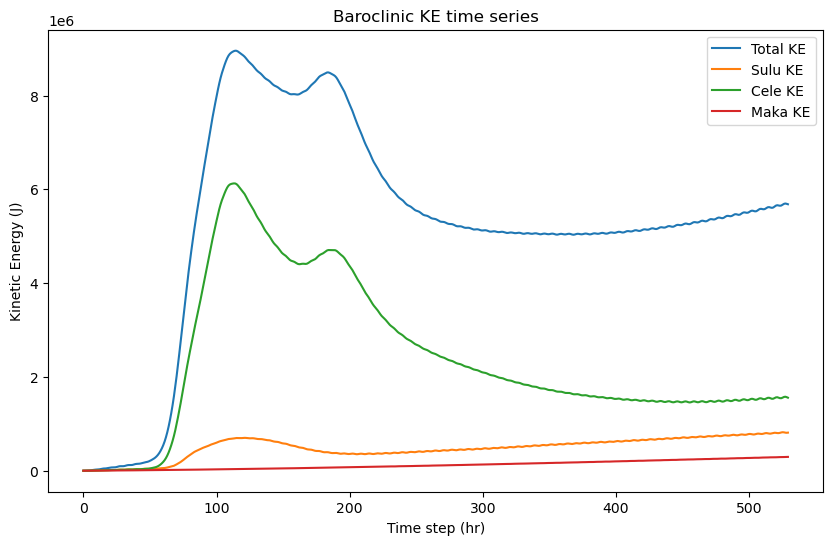

In [41]:
plt.figure(figsize=(10,6))
plt.plot(ke_bc_tseries_hsum, label='Total KE')
plt.plot(ke_bc_tseries_sulu, label='Sulu KE')
plt.plot(ke_bc_tseries_cele, label='Cele KE')
plt.plot(ke_bc_tseries_maka, label='Maka KE')
plt.legend()
plt.title('Baroclinic KE time series')
plt.xlabel('Time step (hr)')
plt.ylabel('Kinetic Energy (J)')
# plt.plot(ke_bt_tseries_hsum, label='Sulu KE')

In [39]:
# save all the energy terms to a csv file
df_ke = pd.DataFrame({
    'ke_bt_total': ke_bt_tseries_hsum,
    'ke_bt_sulu': ke_bt_tseries_sulu,
    'ke_bt_cele': ke_bt_tseries_cele,
    'ke_bt_maka': ke_bt_tseries_maka,
    'ke_bc_total': ke_bc_tseries_hsum,
    'ke_bc_sulu': ke_bc_tseries_sulu,
    'ke_bc_cele': ke_bc_tseries_cele,
    'ke_bc_maka': ke_bc_tseries_maka,
})
df_ke.to_csv('ke_time_series.csv', index=False) 

In [ ]:
## calculate total KE
ke_tseries_hsum = []
ke_tseries_sulu = []
ke_tseries_cele = []
ke_tseries_maka = []

for it in tqdm(500):
        # print(f'Processing time step for BC case: {it}')
        itt = it*180
        u = read_mds(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/ctrl/outs_sn.{itt:010d}',)
        v = read_mds(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/ctrl/outs_sn.{itt:010d}',)

        ubc = u['UVEL'].compute() - u2d[it-it1]
        vbc = v['VVEL'].compute() - v2d[it-it1]

        ke_bc = 0.5*(ubc**2 + vbc**2) * drF['DRF'].compute() * hFacS['hFacS'].compute()* rho0
        ke_bc_hsum = np.nansum(ke_bc, axis=(0,1,2))
        ke_bc_sulu = np.nansum(ke_bc * mask_sulu, axis=(0,1,2))
        ke_bc_cele = np.nansum(ke_bc * mask_cele, axis=(0,1,2))
        ke_bc_maka = np.nansum(ke_bc * mask_maka, axis=(0,1,2))
        ke_bc_tseries_hsum.append(ke_bc_hsum)
        ke_bc_tseries_sulu.append(ke_bc_sulu)
        ke_bc_tseries_cele.append(ke_bc_cele)
        ke_bc_tseries_maka.append(ke_bc_maka)


In [52]:
u_lat3_lon120 = []
v_lat3_lon120 = []
for im in range(5):
    print(im)
    it1 = im*100
    it2 = (im+1)*100
    ds_bt_u = xr.open_dataset(f'case_ctrl/u_2d_frombc_t_{it1}_to_{it2}.nc')
    ds_bt_v = xr.open_dataset(f'case_ctrl/v_2d_frombc_t_{it1}_to_{it2}.nc')
    u_lat3_lon120_part = ds_bt_u['__xarray_dataarray_variable__'].isel(YC=630, XG=1000).values
    u_lat3_lon120.append(u_lat3_lon120_part)
    v_lat3_lon120_part = ds_bt_v['__xarray_dataarray_variable__'].isel(YG=630, XC=1000).values
    v_lat3_lon120.append(v_lat3_lon120_part)

0
1
2
3
4


In [53]:
u_lat3_lon120 = np.concatenate(u_lat3_lon120)
v_lat3_lon120 = np.concatenate(v_lat3_lon120)


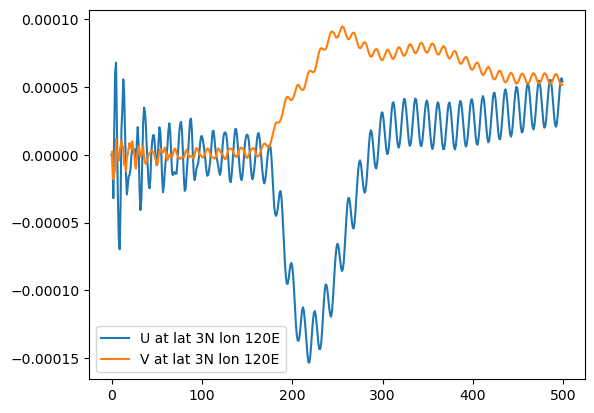

In [54]:
plt.plot(u_lat3_lon120, label='U at lat 3N lon 120E')
plt.plot(v_lat3_lon120, label='V at lat 3N lon 120E')
plt.legend()

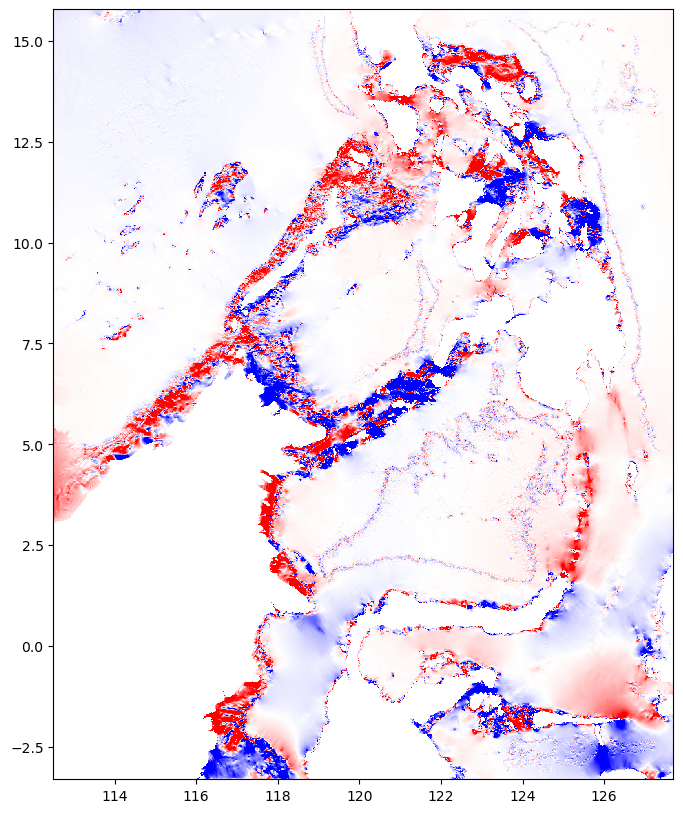

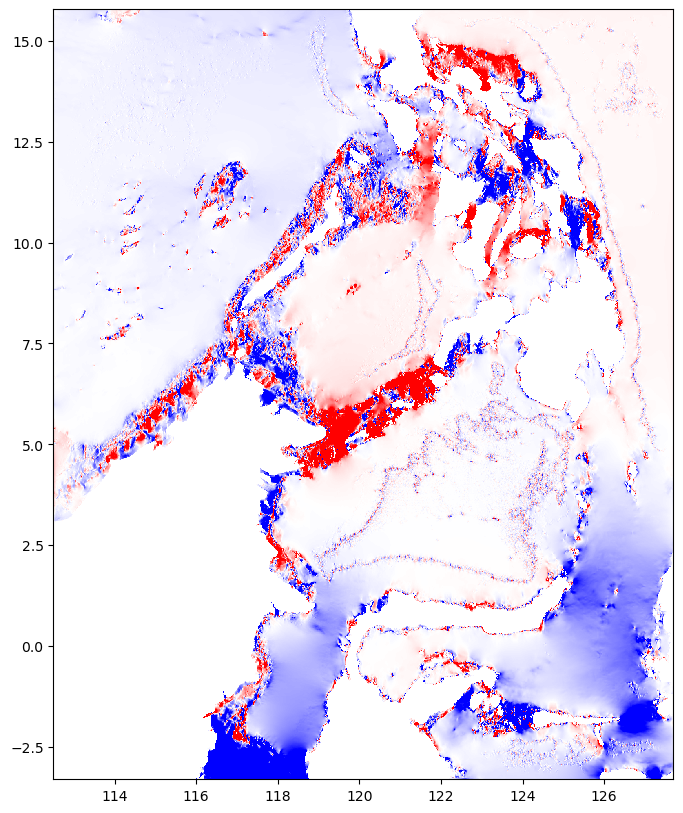

In [9]:
ds_bt_u_end = xr.open_dataset(f'case_ctrl/u_2d_frombc_t_100_to_200.nc')
ds_bt_v_end = xr.open_dataset(f'case_ctrl/v_2d_frombc_t_100_to_200.nc')

plt.figure(figsize=(8,10))
plt.pcolormesh(lon,lat,ds_bt_u_end['__xarray_dataarray_variable__'].isel(time=0).values,vmax=0.001, vmin=-0.001,cmap='bwr')

plt.figure(figsize=(8,10))
plt.pcolormesh(lon,lat,ds_bt_v_end['__xarray_dataarray_variable__'].isel(time=0).values,vmax=0.001, vmin=-0.001,cmap='bwr')

In [6]:
ds_bt_u_100_200 = xr.open_dataset(f'case_ctrl/u_2d_frombc_t_100_to_200.nc')
ds_bt_v_100_200 = xr.open_dataset(f'case_ctrl/v_2d_frombc_t_100_to_200.nc')
ds_bt_u_500 = xr.open_dataset(f'case_ctrl/u_2d_frombc_t_500_to_530.nc')
ds_bt_v_500 = xr.open_dataset(f'case_ctrl/v_2d_frombc_t_500_to_530.nc')
ds_t500 = read_mds(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/ctrl/outs_sn.{500*180:010d}',)
u3d= ds_t500['UVEL'].compute()-ds_bt_u_500['__xarray_dataarray_variable__'][0,:,:].values
v3d = ds_t500['VVEL'].compute()-ds_bt_v_500['__xarray_dataarray_variable__'][0,:,:].values
ds_t200 = read_mds(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/ctrl/outs_sn.{100*180:010d}',)
u3d_200= ds_t200['UVEL'].compute()-ds_bt_u_100_200['__xarray_dataarray_variable__'][0,:,:].values
v3d_200 = ds_t200['VVEL'].compute()-ds_bt_v_100_200['__xarray_dataarray_variable__'][0,:,:].values

ke_bc_500 = 0.5*(u3d**2 + v3d**2) * drF['DRF'].compute() * hFacS['hFacS'].compute()* rho0
ke_bc_500_vsum = np.nansum(ke_bc_500, axis=0)
ke_bc_500_vsum[ke_bc_500_vsum==0]=np.nan

ke_bc_200 = 0.5*(u3d_200**2 + v3d_200**2) * drF['DRF'].compute() * hFacS['hFacS'].compute()* rho0
ke_bc_200_vsum = np.nansum(ke_bc_200, axis=0)
ke_bc_200_vsum[ke_bc_200_vsum==0]=np.nan    

# u3d_lat3_lon120 = u3d[:,630,1000]
# v3d_lat3_lon120 = v3d[:,630,1000]
# u3d_200_lat3_lon120 = u3d_200[:,630,1000]
# v3d_200_lat3_lon120 = v3d_200[:,630,1000]

# plt.plot(u3d_lat3_lon120, label='U 3D at lat 3N lon 120E')
# plt.plot(v3d_lat3_lon120, label='V 3D at lat 3N lon 120E')
# plt.plot(u3d_200_lat3_lon120, label='U 2D at lat 3N lon 120E')
# plt.plot(v3d_200_lat3_lon120, label='V 2D at lat 3N lon 120E')
# plt.legend()


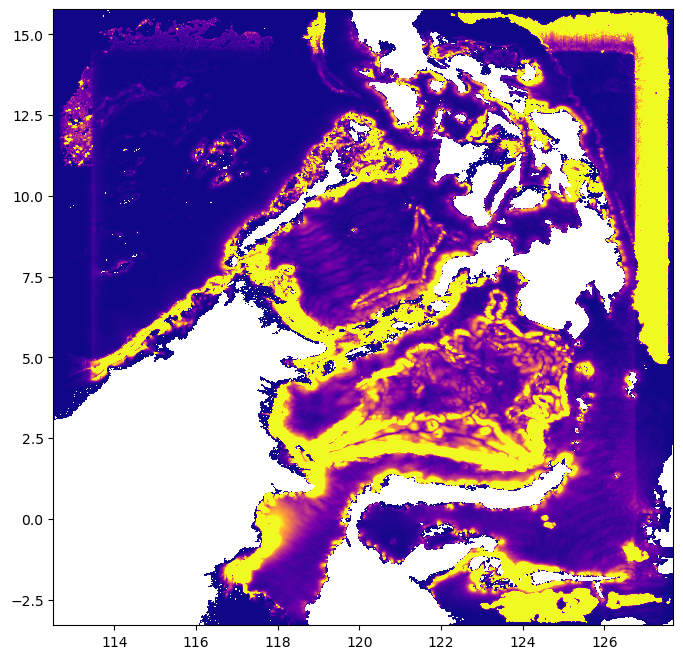

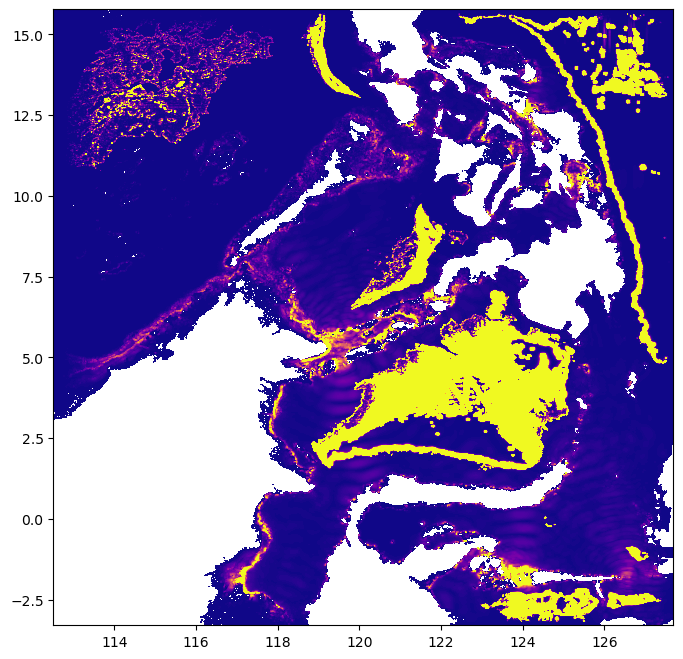

In [7]:

plt.figure(figsize=(8,8))
plt.contourf(lon,lat,ke_bc_500_vsum,vmax=5.5, levels=np.arange(0,5.55,0.05), vmin=0,extend = 'max',cmap='plasma')

plt.figure(figsize=(8,8))
plt.contourf(lon,lat,ke_bc_200_vsum,vmax=5.5, levels=np.arange(0,5.55,0.05), vmin=0,extend = 'max',cmap='plasma')

In [5]:
# get the bottom velocity 
u3d_bot = []
v3d_bot = []
for it in tqdm(range(0, 300, 3)):
    # print(f'Processing time step for BC case: {it}')
    itt = it*180
    ds_0 = read_mds(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/ctrl/outs_sn.{itt:010d}',)
    u = ds_0['UVEL'][-1,:,:].compute()
    v = ds_0['VVEL'][-1,:,:].compute()

    u3d_bot.append(u)
    v3d_bot.append(v)

u3d_bot = np.array(u3d_bot)
v3d_bot = np.array(v3d_bot)



100%|██████████| 100/100 [08:45<00:00,  5.25s/it]


IndexError: index 100 is out of bounds for axis 0 with size 100

<Figure size 800x1000 with 0 Axes>

In [23]:
u3d_bot[u3d_bot==0]=np.nan
v3d_bot[v3d_bot==0]=np.nan

plt.figure(figsize=(10,10))
for it in range(0, 300, 3):
# for it in range(197,200,3):
    plt.pcolormesh(lon,lat,np.sqrt(u3d_bot[it//3,:,:]**2 + v3d_bot[it//3,:,:]**2),vmax=0.003,cmap='Reds')
    plt.colorbar(label='Bottom velocity (m/s)')
    iskp = 10
    plt.quiver(lon[::iskp, ::iskp], lat[::iskp, ::iskp], 
               u3d_bot[it//3, ::iskp, ::iskp], v3d_bot[it//3, ::iskp, ::iskp], 
               color='black', scale=0.1, width=0.001)
    plt.title(f'Bottom velocity vectors at {it} hours')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.savefig(f'case_ctrl/bottom_vel/bottom_velocity_{it}.png')
    plt.clf()

    get_ram_info()

Used RAM  : 10487918592
Used RAM  : 10591293440
Used RAM  : 10347462656
Used RAM  : 10359042048
Used RAM  : 10319081472
Used RAM  : 10301747200
Used RAM  : 10267754496
Used RAM  : 10174636032
Used RAM  : 10070532096
Used RAM  : 10167029760
Used RAM  : 10189381632
Used RAM  : 10118127616
Used RAM  : 10222694400
Used RAM  : 10159939584
Used RAM  : 10105745408
Used RAM  : 10081734656
Used RAM  : 10028081152
Used RAM  : 10115112960
Used RAM  : 10074165248
Used RAM  : 10170404864
Used RAM  : 10269835264
Used RAM  : 10158428160
Used RAM  : 10059366400
Used RAM  : 10191138816
Used RAM  : 10045411328
Used RAM  : 9978089472
Used RAM  : 10110824448
Used RAM  : 10049409024
Used RAM  : 10137436160
Used RAM  : 10028707840
Used RAM  : 9967333376
Used RAM  : 10107564032
Used RAM  : 10064838656
Used RAM  : 9981448192
Used RAM  : 10131247104
Used RAM  : 10044624896
Used RAM  : 10137047040
Used RAM  : 10006941696
Used RAM  : 10003193856
Used RAM  : 10091671552
Used RAM  : 10070208512
Used RAM  : 9976442

<Figure size 1000x1000 with 0 Axes>

In [24]:
# Create MP4 animation from the bottom velocity figures
import imageio.v2 as imageio

# List to store image frames
frames = []

# Load all the saved PNG files
for it in range(0, 300, 3):
    filename = f'case_ctrl/bottom_vel/bottom_velocity_{it}.png'
    frames.append(imageio.imread(filename))

# Save as MP4 video
imageio.mimsave('case_ctrl/bottom_vel/bottom_velocity_animation.mp4', 
                frames, 
                fps=10,  # frames per second
                codec='libx264')

print("Animation saved as bottom_velocity_animation.mp4")

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1000, 1000) to (1008, 1008) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Animation saved as bottom_velocity_animation.mp4


In [ ]:
# Bottom temperature snapshots and animation
os.makedirs('case_ctrl/bottom_temp', exist_ok=True)

t3d_bot = []
for it in tqdm(range(0, 300, 3)):
    itt = it * 180
    ds_0 = read_mds(f'/home/ceoas/liux8/work/basin_modes/sulu_sea/linear_tests/ctrl/outs_sn.{itt:010d}',)
    t = ds_0['THETA'][-1, :, :].compute()
    t3d_bot.append(t)

t3d_bot = np.array(t3d_bot)
t3d_bot[t3d_bot == 0] = np.nan


In [26]:
for it in tqdm(range(0, 300, 3)):
    plt.pcolormesh(lon, lat, t3d_bot[it // 3, :, :], cmap='Spectral_r', vmin=4.648, vmax=4.652)
    plt.colorbar(label='Bottom temperature (°C)')
    plt.title(f'Bottom temperature at {it} hours')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.savefig(f'case_ctrl/bottom_temp/bottom_temp_{it}.png')
    plt.clf()
    get_ram_info()

# Create MP4 animation from the bottom temperature figures
frames = []
for it in tqdm(range(0, 300, 3)):
    filename = f'case_ctrl/bottom_temp/bottom_temp_{it}.png'
    frames.append(imageio.imread(filename))

imageio.mimsave('case_ctrl/bottom_temp/bottom_temp_animation.mp4', frames, fps=10, codec='libx264')
print("Animation saved as bottom_temp_animation.mp4")

  1%|          | 1/100 [00:02<04:25,  2.68s/it]

Used RAM  : 13049118720


  2%|▏         | 2/100 [00:05<04:21,  2.67s/it]

Used RAM  : 12995977216


  3%|▎         | 3/100 [00:08<04:18,  2.67s/it]

...

100%|██████████| 100/100 [04:33<00:00,  2.74s/it]


Used RAM  : 13353799680


100%|██████████| 100/100 [00:00<00:00, 105.18it/s]


Animation saved as bottom_temp_animation.mp4


<Figure size 640x480 with 0 Axes>

Text(0, 0.5, 'Latitude')

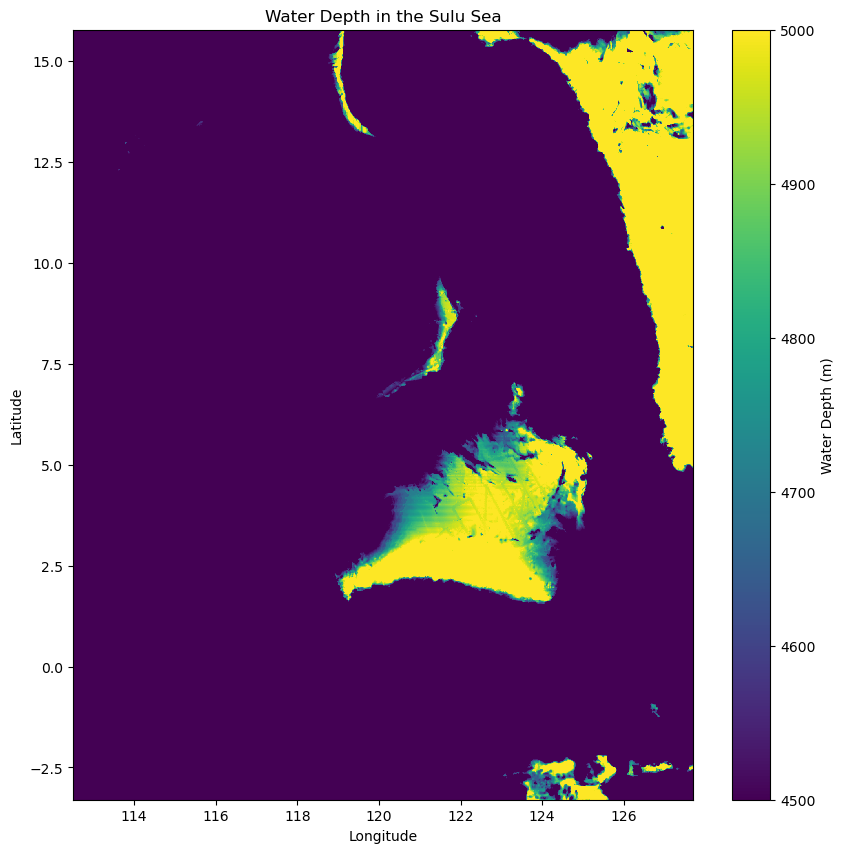

In [29]:
# plot water depth
plt.figure(figsize=(10,10))
plt.pcolormesh(lon, lat, Depth['Depth'].compute(), cmap='viridis', vmin=4500, vmax=5000)
plt.colorbar(label='Water Depth (m)')
plt.title('Water Depth in the Sulu Sea')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# OLD STUFF, should be deleted
# --- IGNORE ---